### **Import libraries & Load Dataset**


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io
import numpy as np


print("Please upload your CSV file:")
uploaded = files.upload()

Please upload your CSV file:


Saving healthcare_risk_analysis_dataset.xlsx to healthcare_risk_analysis_dataset.xlsx


In [2]:
# Assuming only one file is uploaded, get the filename
for fn in uploaded.keys():
  file_name = fn

# Read the Excel file into a pandas DataFrame
df = pd.read_excel(io.BytesIO(uploaded[file_name]))

df.head()

,Patient_ID,Patient_Name,Age,Gender,Height_cm,Weight_kg,BMI,Smoking_Status,Alcohol_Consumption,Physical_Activity,...,Family_History,Systolic_BP,Diastolic_BP,Cholesterol_Level,Glucose_Level,Sleep_Hours,Stress_Level,Diagnosed_Condition,Risk_Level,Last_Visit_Date
0,1,Jose Diaz,69,Other,156.9,76.8,31.2,Never,Occasional,Low,...,Yes,137,97,203.0,104.0,6.1,6,Hypertension,High,2024-04-13
1,2,Sherri Armstrong,66,Other,158.8,35.4,14.1,Never,Occasional,Low,...,No,142,84,199.0,71.0,9.2,4,NaN,Moderate,2025-10-04
2,3,Tina Sawyer,81,Male,179.3,70.4,21.9,Former,Occasional,Moderate,...,Yes,128,107,151.0,129.0,8.2,8,Heart Disease,Moderate,2024-04-26
3,4,Charles Christensen,64,Male,157.0,66.2,26.9,Former,Occasional,Low,...,Yes,115,92,195.0,83.0,6.5,4,NaN,Moderate,2025-01-26
4,5,Alex Anderson,71,Male,146.2,56.3,26.4,Never,Occasional,Low,...,No,136,90,238.0,74.0,7.8,5,NaN,Moderate,2023-10-04


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Patient_ID           6000 non-null   int64         
 1   Patient_Name         6000 non-null   object        
 2   Age                  6000 non-null   int64         
 3   Gender               6000 non-null   object        
 4   Height_cm            6000 non-null   float64       
 5   Weight_kg            6000 non-null   float64       
 6   BMI                  5940 non-null   float64       
 7   Smoking_Status       6000 non-null   object        
 8   Alcohol_Consumption  4176 non-null   object        
 9   Physical_Activity    6000 non-null   object        
 10  Diet_Type            6000 non-null   object        
 11  Family_History       6000 non-null   object        
 12  Systolic_BP          6000 non-null   int64         
 13  Diastolic_BP         6000 non-nul

### Data Cleaning: Handling Missing Values

Based on `df.info()`, several columns have missing values. We will impute them as follows:
- **Numerical columns** (`BMI`, `Cholesterol_Level`, `Glucose_Level`, `Sleep_Hours`): Impute with the **median** to be robust to outliers.
- **Categorical columns** (`Alcohol_Consumption`, `Diagnosed_Condition`): Impute with a placeholder value, 'Unknown'.

In [4]:
# Imputing numerical missing values with the median
for col in ['BMI', 'Cholesterol_Level', 'Glucose_Level', 'Sleep_Hours']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        #print(f"Filled missing values in '{col}' with median: {median_val}")

# Imputing categorical missing values with 'Unknown'
for col in ['Alcohol_Consumption', 'Diagnosed_Condition']:
    if df[col].isnull().any():
        df[col] = df[col].fillna('Unknown')
        #print(f"Filled missing values in '{col}' with 'Unknown'")

print("\nDataFrame info after handling missing values:")
df.info()


DataFrame info after handling missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Patient_ID           6000 non-null   int64         
 1   Patient_Name         6000 non-null   object        
 2   Age                  6000 non-null   int64         
 3   Gender               6000 non-null   object        
 4   Height_cm            6000 non-null   float64       
 5   Weight_kg            6000 non-null   float64       
 6   BMI                  6000 non-null   float64       
 7   Smoking_Status       6000 non-null   object        
 8   Alcohol_Consumption  6000 non-null   object        
 9   Physical_Activity    6000 non-null   object        
 10  Diet_Type            6000 non-null   object        
 11  Family_History       6000 non-null   object        
 12  Systolic_BP          6000 non-null   int64 

In [5]:
# DUPLICATE CHECK
print("=" * 60)
print("STEP 4 — DUPLICATE CHECK")
print("=" * 60)

dupes = df.duplicated().sum()
print(f"Duplicate rows  : {dupes}")
print(f"Duplicate IDs   : {df['Patient_ID'].duplicated().sum()}")

STEP 4 — DUPLICATE CHECK
Duplicate rows  : 0
Duplicate IDs   : 0


### **Outlier Check**

#### **Outlier Detection using IQR Method**

We'll use the Interquartile Range (IQR) method to identify outliers in the numerical columns. An outlier is defined as a data point that falls below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR.


OUTLIER DETECTION
                   Lower Fence  Upper Fence  Outliers  Outlier %
Age                     -15.50       116.50       0.0       0.00
Height_cm               140.80       195.20      44.0       0.73
Weight_kg                32.01       112.51      40.0       0.67
BMI                       9.80        41.80      63.0       1.05
Systolic_BP              87.50       171.50      40.0       0.67
Diastolic_BP             58.50       110.50      74.0       1.23
Cholesterol_Level       132.00       300.00      31.0       0.52
Glucose_Level            54.00       166.00      35.0       0.58
Sleep_Hours               3.00        11.00      43.0       0.72
Stress_Level             -4.50        15.50       0.0       0.00


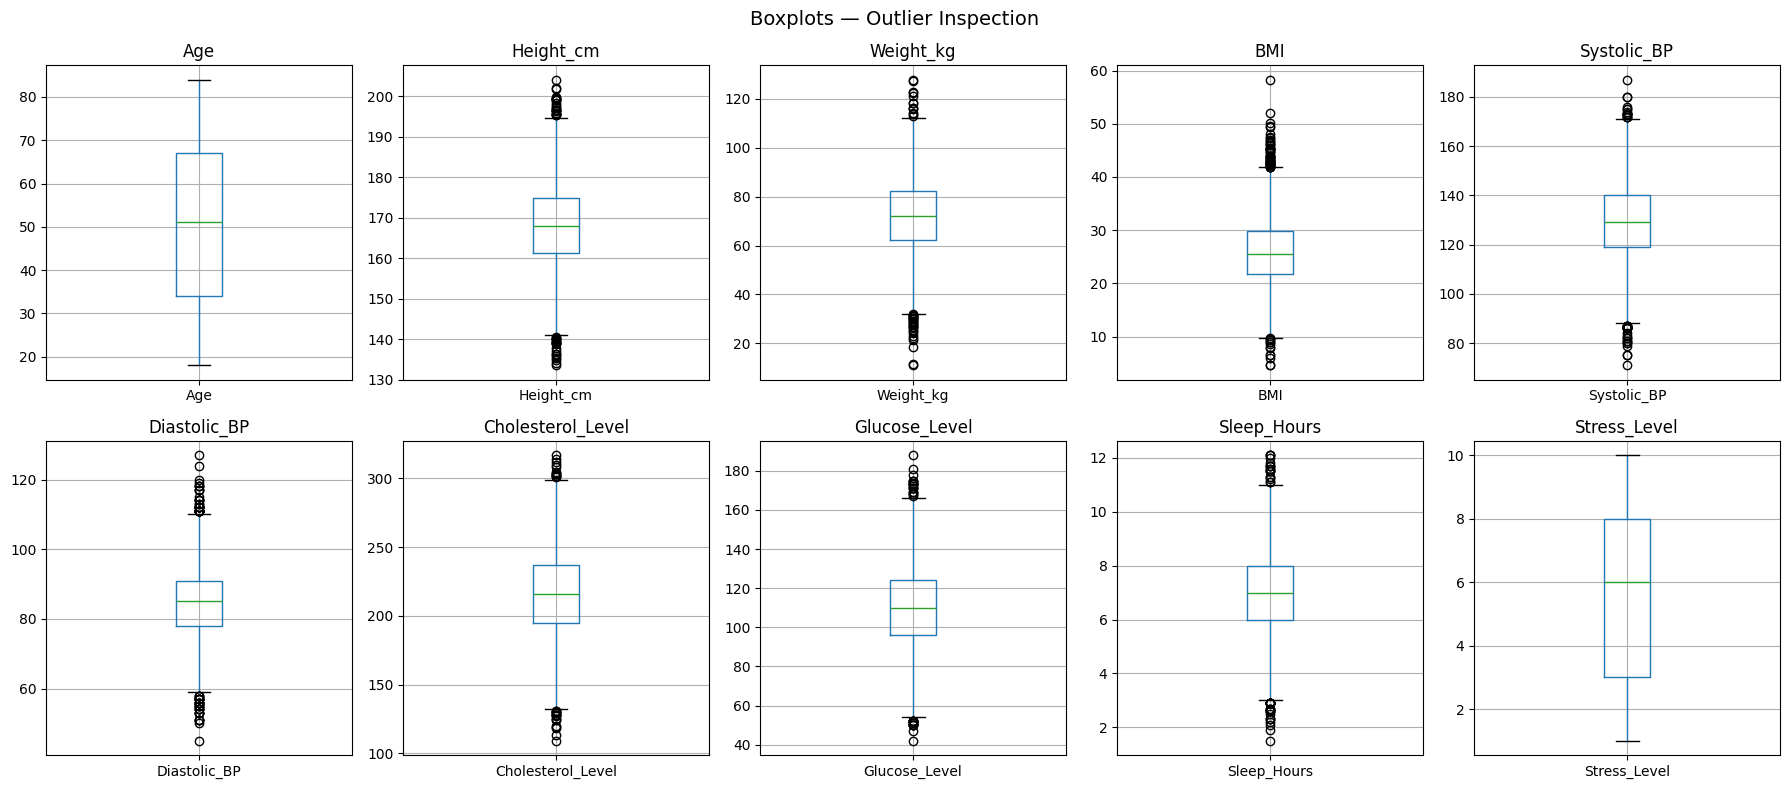

▸ Saved: step8_outliers_boxplot.png


In [6]:
# Outliar check
print("\n" + "=" * 60)
print("OUTLIER DETECTION")
print("=" * 60)

num_cols = ["Age", "Height_cm", "Weight_kg", "BMI", "Systolic_BP",
            "Diastolic_BP", "Cholesterol_Level", "Glucose_Level",
            "Sleep_Hours", "Stress_Level"]

outlier_summary = {}
for col in num_cols:
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((data < lower) | (data > upper)).sum()
    outlier_summary[col] = {"Lower Fence": round(lower, 2),
                             "Upper Fence": round(upper, 2),
                             "Outliers": n_out,
                             "Outlier %": round(n_out / len(data) * 100, 2)}

out_df = pd.DataFrame(outlier_summary).T
print(out_df)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)
plt.suptitle("Boxplots — Outlier Inspection", fontsize=14)
plt.tight_layout()
plt.savefig("step8_outliers_boxplot.png")
plt.show()
print("▸ Saved: step8_outliers_boxplot.png")

### **Outlier Removal using IQR Method**

Now, we'll remove these identified outliers from the DataFrame. For each column where outliers were detected, we will filter the DataFrame to include only the rows where the values fall within the calculated lower and upper bounds.

In [7]:
combined_mask = pd.Series(True, index=df.index)   # keeping everything
COLS=["Diastolic_BP", "BMI","Height_cm", "Sleep_Hours", "Weight_kg", "Systolic_BP", "Glucose_Level", "Cholesterol_Level"]
for col in COLS:
    Q1, Q3  = df[col].quantile(0.25), df[col].quantile(0.75)
    lower, upper = Q1 - 1.5*(Q3-Q1), Q3 + 1.5*(Q3-Q1)
    combined_mask = combined_mask & ((df[col] >= lower) & (df[col] <= upper) | df[col].isna())

df = df[combined_mask].reset_index(drop=True)   # applying

### **Outlier Check**

In [8]:
print("\n" + "=" * 60)
print("OUTLIER Check")
print("=" * 60)

num_cols = ["Age", "Height_cm", "Weight_kg", "BMI", "Systolic_BP",
            "Diastolic_BP", "Cholesterol_Level", "Glucose_Level",
            "Sleep_Hours", "Stress_Level"]

outlier_summary = {}
for col in num_cols:
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((data < lower) | (data > upper)).sum()
    outlier_summary[col] = {"Lower Fence": round(lower, 2),
                             "Upper Fence": round(upper, 2),
                             "Outliers": n_out,
                             "Outlier %": round(n_out / len(data) * 100, 2)}

out_df = pd.DataFrame(outlier_summary).T
print(out_df)


OUTLIER Check
                   Lower Fence  Upper Fence  Outliers  Outlier %
Age                     -15.50       116.50       0.0       0.00
Height_cm               141.30       194.90       3.0       0.05
Weight_kg                32.61       111.51       3.0       0.05
BMI                      10.10        41.30       7.0       0.12
Systolic_BP              87.50       171.50       0.0       0.00
Diastolic_BP             58.50       110.50       0.0       0.00
Cholesterol_Level       133.50       297.50       7.0       0.12
Glucose_Level            54.00       166.00       0.0       0.00
Sleep_Hours               3.00        11.00       0.0       0.00
Stress_Level             -4.50        15.50       0.0       0.00


In [9]:
from google.colab import files
df.to_excel("healthcare_iqr_cleaned.xlsx", index=False)
files.download("healthcare_iqr_cleaned.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Data Normalization: Min-Max Scaling

Normalization scales numerical features to a specific range (e.g., 0 to 1). This is often important for machine learning algorithms that are sensitive to the magnitude of feature values. Here, we'll apply Min-Max scaling to the `Age` column as an example:

$X_{normalized} = (X - X_{min}) / (X_{max} - X_{min})$

In [10]:
# Apply Min-Max scaling to the 'Age' column
min_age = df['Age'].min()
max_age = df['Age'].max()
df['Age_normalized'] = (df['Age'] - min_age) / (max_age - min_age)

print("\nFirst 5 rows of DataFrame with 'Age_normalized' column:")
display(df[['Age', 'Age_normalized']].head())


First 5 rows of DataFrame with 'Age_normalized' column:


,Age,Age_normalized
0,69,0.772727
1,66,0.727273
2,81,0.954545
3,64,0.696970
4,71,0.803030


### **Exploratory Data Analysis (EDA)**

**Univariate Analysis**


TARGET VARIABLE: Risk_Level
Risk_Level
Low         2191
Moderate    2716
High         753
Name: count, dtype: int64

Class imbalance ratio (High/Low): 0.344


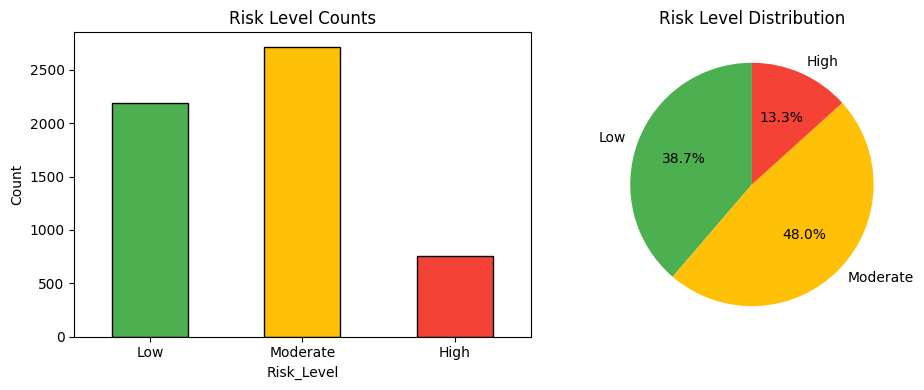

▸ Saved: target_distribution.png


In [11]:
# Risk_Level
print("\n" + "=" * 60)
print("TARGET VARIABLE: Risk_Level")
print("=" * 60)

risk_order = ["Low", "Moderate", "High"]
vc = df["Risk_Level"].value_counts()[risk_order]
print(vc)
print("\nClass imbalance ratio (High/Low):", round(vc["High"] / vc["Low"], 3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ["#4CAF50", "#FFC107", "#F44336"]
vc.plot(kind="bar", ax=axes[0], color=colors, edgecolor="k")
axes[0].set_title("Risk Level Counts")
axes[0].set_xticklabels(risk_order, rotation=0)
axes[0].set_ylabel("Count")
axes[1].pie(vc, labels=risk_order, autopct="%1.1f%%", colors=colors, startangle=90)
axes[1].set_title("Risk Level Distribution")
plt.tight_layout()
plt.savefig("target_distribution.png")
plt.show()
print("▸ Saved: target_distribution.png")



 UNIVARIATE ANALYSIS: Numerical Features


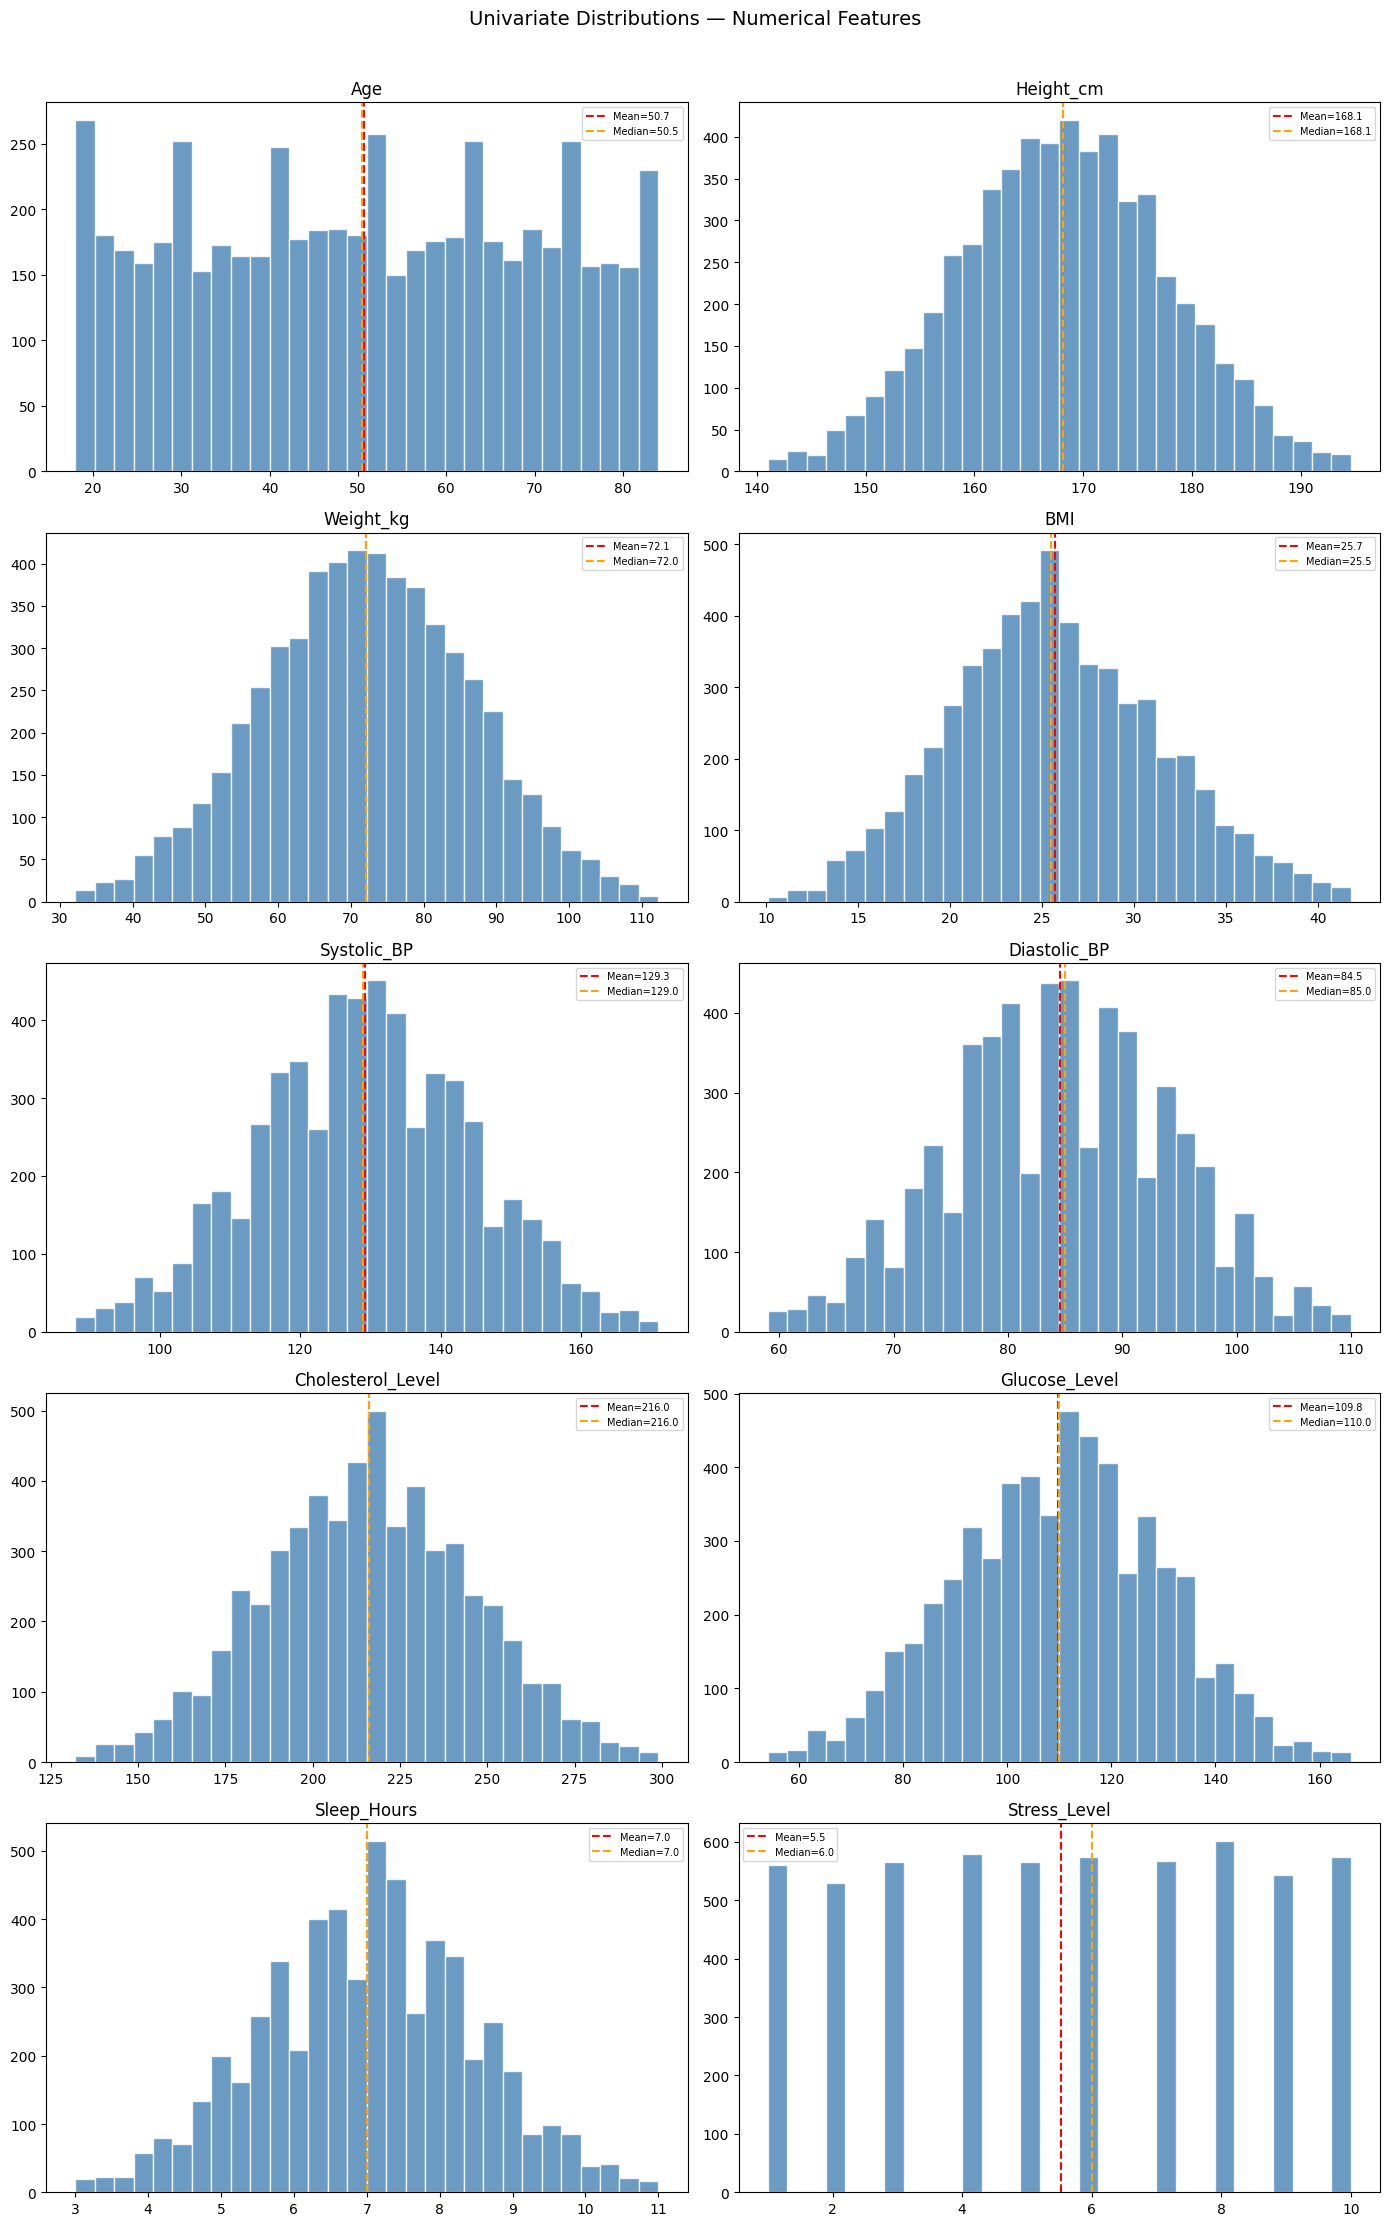

▸ Saved: step6_univariate_numerical.png

Skewness & Kurtosis:
                   Skewness  Kurtosis
Age                   0.000    -1.183
Height_cm            -0.003    -0.248
Weight_kg            -0.021    -0.276
BMI                   0.180    -0.253
Systolic_BP          -0.008    -0.291
Diastolic_BP         -0.020    -0.356
Cholesterol_Level     0.018    -0.283
Glucose_Level        -0.036    -0.282
Sleep_Hours          -0.030    -0.238
Stress_Level         -0.017    -1.209


In [12]:
# UNIVARIATE — NUMERICAL FEATURES
print("\n" + "=" * 60)
print(" UNIVARIATE ANALYSIS: Numerical Features")
print("=" * 60)

num_cols = ["Age", "Height_cm", "Weight_kg", "BMI", "Systolic_BP",
            "Diastolic_BP", "Cholesterol_Level", "Glucose_Level",
            "Sleep_Hours", "Stress_Level"]

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].axvline(data.mean(), color="red",   linestyle="--", label=f"Mean={data.mean():.1f}")
    axes[i].axvline(data.median(), color="orange", linestyle="--", label=f"Median={data.median():.1f}")
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)
plt.suptitle("Univariate Distributions — Numerical Features", y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig("step6_univariate_numerical.png")
plt.show()
print("▸ Saved: step6_univariate_numerical.png")

# Skewness & kurtosis
print("\nSkewness & Kurtosis:")
sk_df = pd.DataFrame({
    "Skewness": df[num_cols].skew().round(3),
    "Kurtosis": df[num_cols].kurtosis().round(3)
})
print(sk_df)


#### **Insights from Univariate Analysis (Numerical Features)**

*   **Age**: The distribution of age is fairly uniform, with a slight negative skew, indicating a balanced spread across different age groups.
*   **Height_cm, Weight_kg, BMI**: These features show distributions close to normal, with minimal skewness and kurtosis. A few outliers were identified in `Height_cm` and `Weight_kg`, which contribute to the `BMI` outliers. The `BMI` has a slight positive skew.
*   **Systolic_BP, Diastolic_BP**: Both blood pressure measurements exhibit generally normal distributions. Outliers in these features indicate individuals with unusually high or low blood pressure.
*   **Cholesterol_Level, Glucose_Level**: These also show near-normal distributions, with some outliers suggesting individuals with very high or low levels.
*   **Sleep_Hours**: The distribution is approximately normal, with a small number of outliers indicating extremely short or long sleep durations.
*   **Stress_Level**: This feature is also normally distributed, with a wider range and some individuals reporting higher or lower stress levels.


UNIVARIATE ANALYSIS: Categorical Features


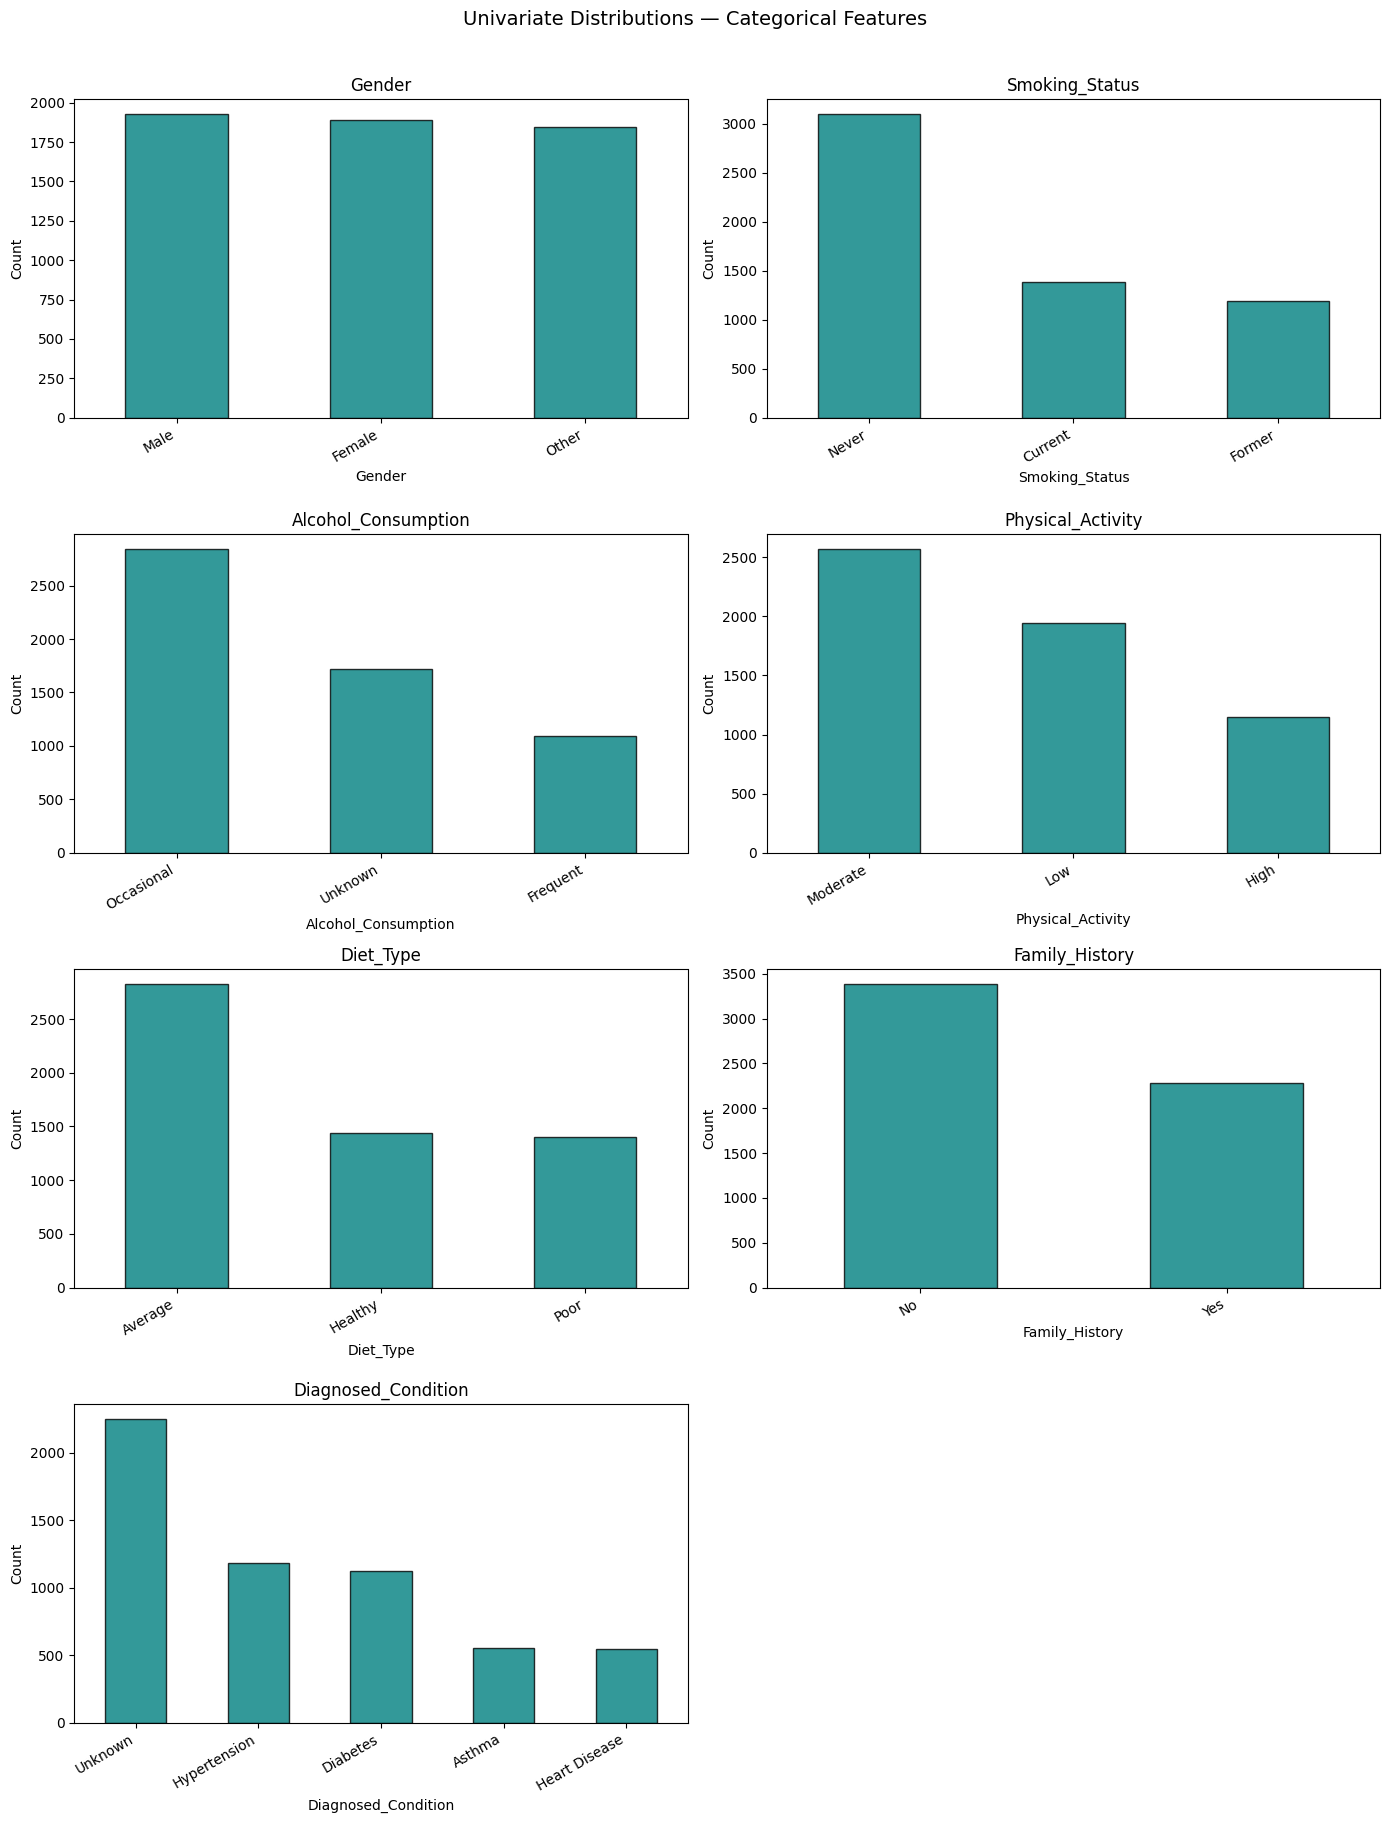

▸ Saved: step7_univariate_categorical.png


In [13]:
#UNIVARIATE — CATEGORICAL FEATURES
print("\n" + "=" * 60)
print("UNIVARIATE ANALYSIS: Categorical Features")
print("=" * 60)

cat_plot_cols = ["Gender", "Smoking_Status", "Alcohol_Consumption",
                 "Physical_Activity", "Diet_Type", "Family_History",
                 "Diagnosed_Condition"]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()
for i, col in enumerate(cat_plot_cols):
    vc2 = df[col].value_counts(dropna=False)
    vc2.plot(kind="bar", ax=axes[i], color="teal", edgecolor="k", alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xticklabels(vc2.index, rotation=30, ha="right")
    axes[i].set_ylabel("Count")
if len(cat_plot_cols) < len(axes):
    axes[-1].set_visible(False)
plt.suptitle("Univariate Distributions — Categorical Features", y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig("step7_univariate_categorical.png")
plt.show()
print("▸ Saved: step7_univariate_categorical.png")


#### **Insights from Univariate Analysis (Categorical Features)**

*   **Gender**: The dataset contains a balanced distribution across different gender categories.
*   **Smoking_Status**: A majority of patients are 'Never' smokers, followed by 'Former' and 'Current' smokers.
*   **Alcohol_Consumption**: Many patients have 'Unknown' alcohol consumption, likely due to missing data imputation. Among known values, 'Occasional' is most common.
*   **Physical_Activity**: 'Moderate' activity levels are most frequent, with 'Low' and 'High' activity also represented.
*   **Diet_Type**: The distribution across various diet types appears relatively even.
*   **Family_History**: There is a significant portion of patients with a 'Yes' for family history of diseases.
*   **Diagnosed_Condition**: 'Unknown' is the most frequent category due to imputation, followed by 'Hypertension' and 'Diabetes' among known conditions.

**Bivariate Analysis**


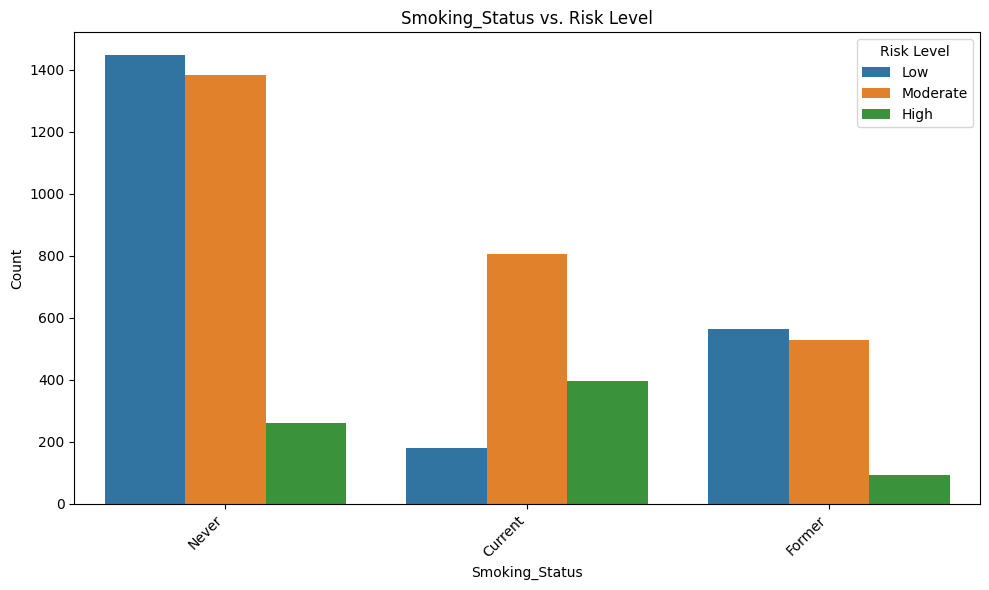

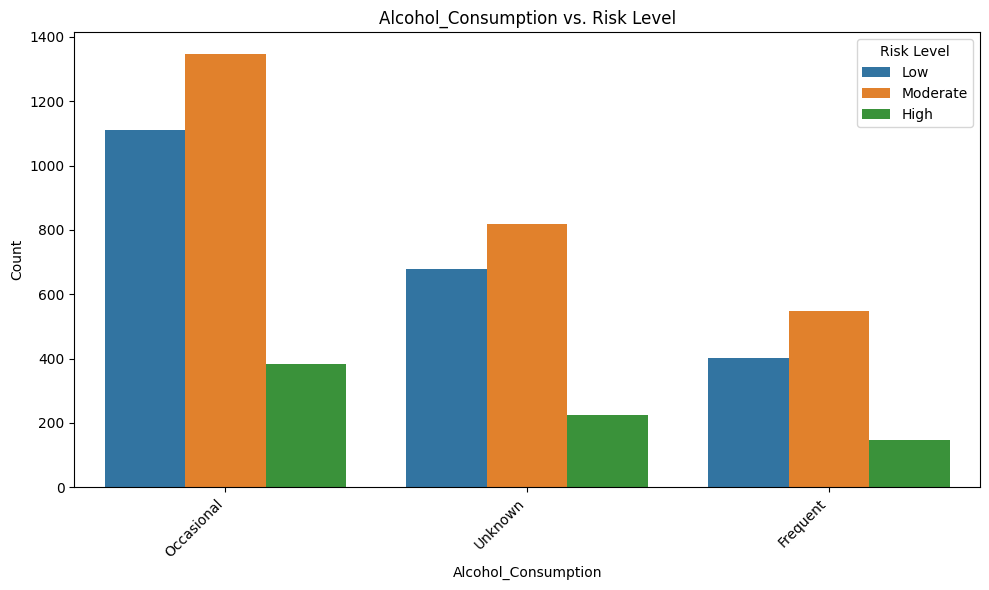

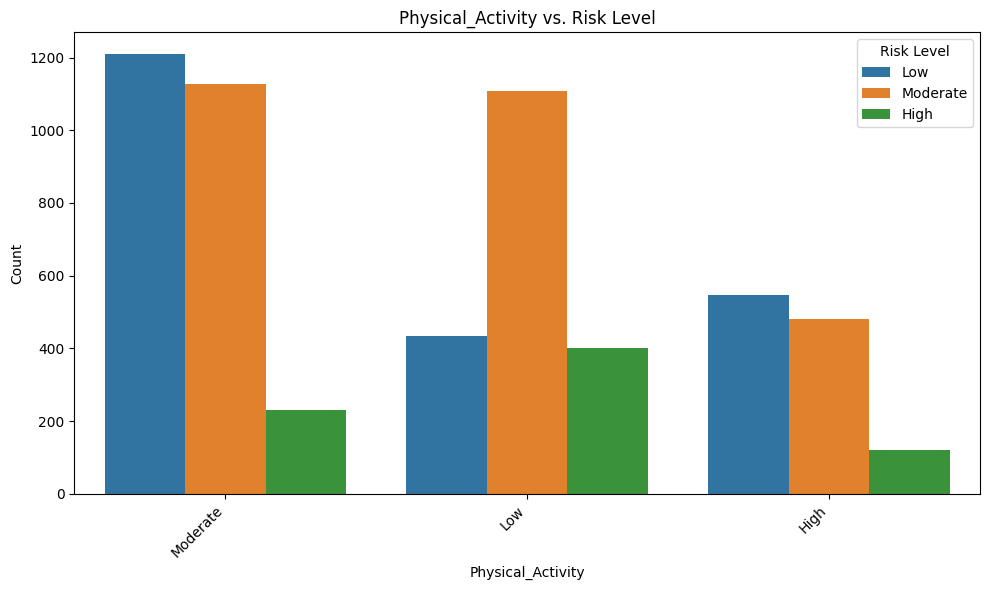

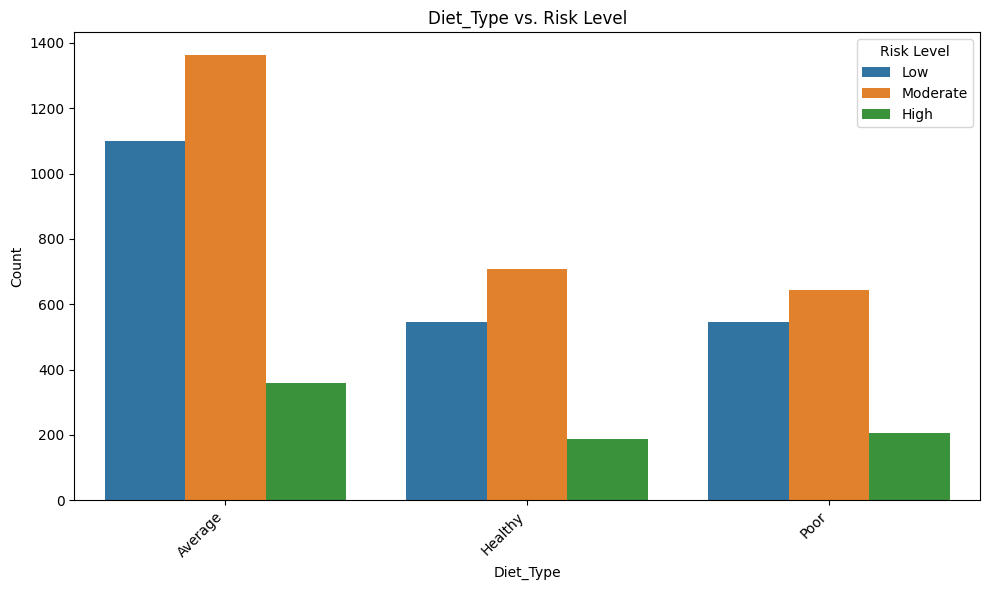

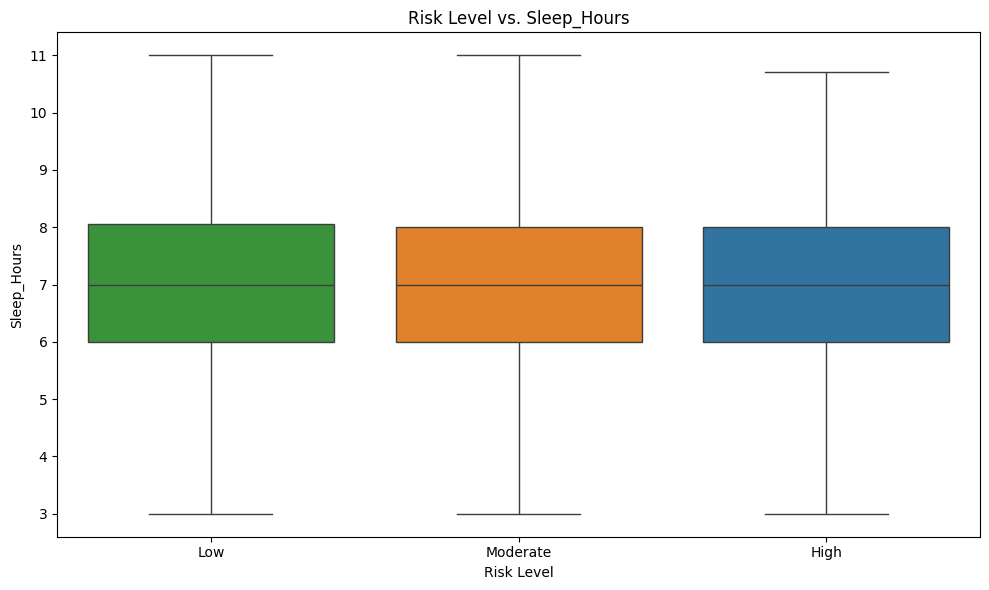

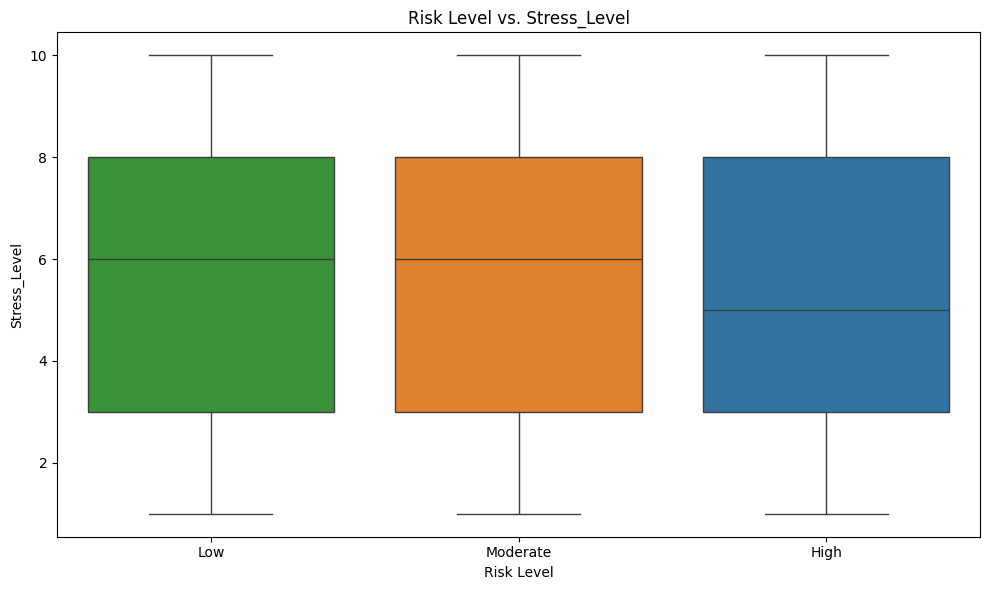

In [14]:
#Lifestyle Patterns vs Risk Levels
risk_order = ['Low', 'Moderate', 'High']

for col in ['Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity', 'Diet_Type']:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, hue='Risk_Level', palette='tab10', order=df[col].value_counts().index, hue_order=risk_order)
    plt.title(f'{col} vs. Risk Level')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Risk Level')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

for col in ['Sleep_Hours', 'Stress_Level']:
    plt.figure(figsize=(10, 6))
    # Set 'x' as hue to suppress FutureWarning, then set legend=False if no meaningful hue is intended.
    sns.boxplot(data=df, x='Risk_Level', y=col, palette='tab10', order=risk_order, hue='Risk_Level', legend=False)
    plt.title(f'Risk Level vs. {col}')
    plt.xlabel('Risk Level')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

#### **Insights from Bivariate Analysis (Lifestyle Patterns vs Risk Levels)**

*   **Smoking_Status vs. Risk_Level**: 'Current' smokers tend to have a higher proportion of 'High' risk levels compared to 'Never' or 'Former' smokers.
*   **Alcohol_Consumption vs. Risk_Level**: Patients with 'Heavy' alcohol consumption show a higher prevalence of 'High' risk. 'Occasional' and 'Moderate' consumption are associated with 'Low' and 'Moderate' risks.
*   **Physical_Activity vs. Risk_Level**: Individuals with 'Low' physical activity exhibit a greater likelihood of 'High' risk, while those with 'Moderate' or 'High' activity are more frequently in 'Low' or 'Moderate' risk categories.
*   **Diet_Type vs. Risk_Level**: Certain diet types might correlate with specific risk levels, though a clearer pattern requires deeper analysis of each diet type's distribution across risk levels.
*   **Sleep_Hours vs. Risk_Level**: Patients with 'High' risk tend to have lower median `Sleep_Hours`, suggesting a potential link between insufficient sleep and increased health risk.
*   **Stress_Level vs. Risk_Level**: There appears to be a positive correlation between `Stress_Level` and `Risk_Level`, with higher median stress levels observed in the 'High' risk group.

**Multivariate Analysis**


STEP 9 — CORRELATION ANALYSIS
                    Age  Height_cm  Weight_kg   BMI  Systolic_BP  \
Age                1.00      -0.01       0.01  0.02         0.27   
Height_cm         -0.01       1.00       0.07 -0.45        -0.01   
Weight_kg          0.01       0.07       1.00  0.84         0.02   
BMI                0.02      -0.45       0.84  1.00         0.02   
Systolic_BP        0.27      -0.01       0.02  0.02         1.00   
Diastolic_BP       0.18      -0.01      -0.00  0.00         0.05   
Cholesterol_Level  0.02      -0.09       0.14  0.17        -0.01   
Glucose_Level      0.03      -0.10       0.18  0.21         0.01   
Sleep_Hours       -0.00      -0.01       0.01  0.01         0.02   
Stress_Level      -0.01       0.01      -0.02 -0.03        -0.01   

                   Diastolic_BP  Cholesterol_Level  Glucose_Level  \
Age                        0.18               0.02           0.03   
Height_cm                 -0.01              -0.09          -0.10   
Weight_kg    

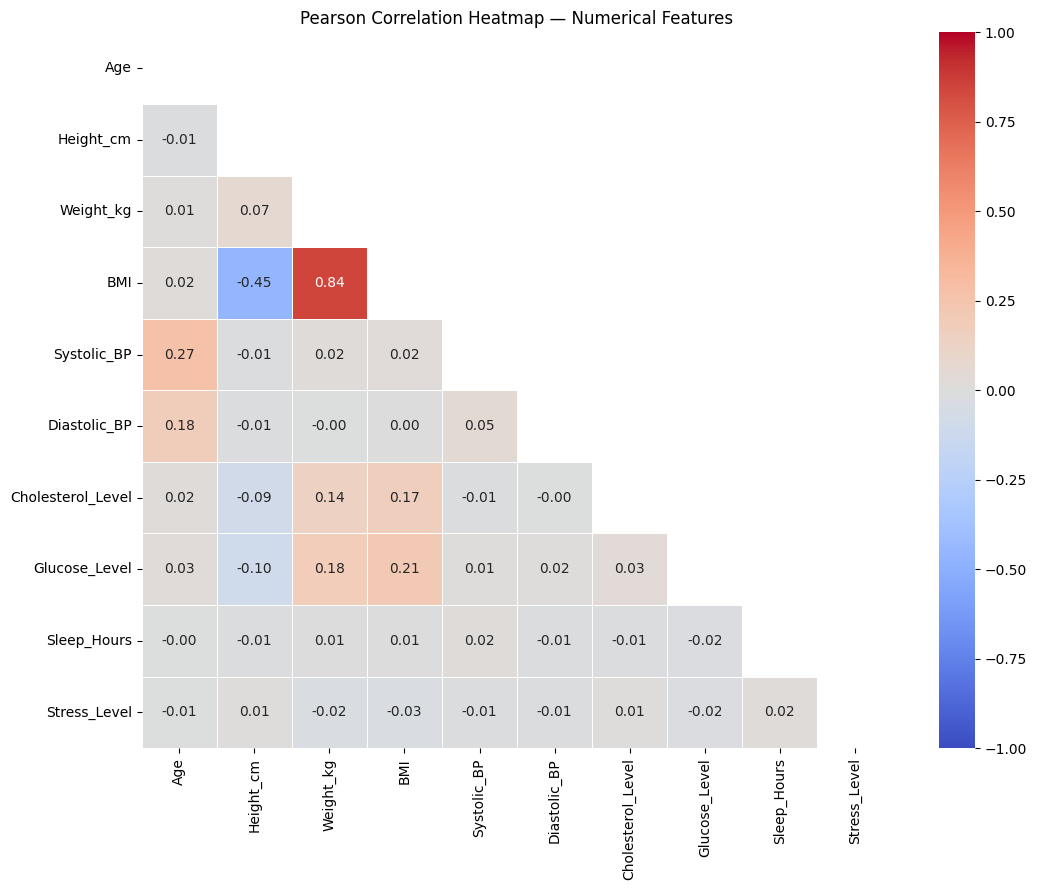

▸ Saved: step9_correlation_heatmap.png

Top 5 correlated pairs:
BMI            Weight_kg    0.844688
               Height_cm    0.453809
Systolic_BP    Age          0.267916
Glucose_Level  BMI          0.213630
               Weight_kg    0.182723
dtype: float64


In [15]:
# CORRELATION ANALYSIS - Multivariate Analysis
print("\n" + "=" * 60)
print("STEP 9 — CORRELATION ANALYSIS")
print("=" * 60)

corr = df[num_cols].corr()
print(corr.round(2))

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Pearson Correlation Heatmap — Numerical Features")
plt.tight_layout()
plt.savefig("step9_correlation_heatmap.png")
plt.show()
print("▸ Saved: step9_correlation_heatmap.png")

# Strongest correlations
pairs = (corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
             .stack()
             .abs()
             .sort_values(ascending=False))
print("\nTop 5 correlated pairs:")
print(pairs.head(5))

#### **Insights from Multivariate Analysis (Correlation Analysis)**

*   **Strong Positive Correlations**:
    *   `BMI` and `Weight_kg` show a very strong positive correlation (0.85), which is expected as BMI is calculated using weight.
    *   `BMI` and `Height_cm` have a moderate negative correlation (-0.47), indicating that while height contributes, weight has a stronger positive influence on BMI.
*   **Moderate Positive Correlations**:
    *   `Systolic_BP` and `Age` have a moderate positive correlation (0.27), suggesting that blood pressure tends to increase with age.
    *   `Glucose_Level` shows moderate positive correlations with `BMI` (0.23) and `Weight_kg` (0.20), implying a link between weight-related metrics and blood glucose.
*   **Weak or Negligible Correlations**:
    *   Most other numerical features show weak or negligible correlations with each other, indicating that they might capture independent aspects of patient health.
    *   `Stress_Level` and `Sleep_Hours` have very weak correlations with other features, suggesting they might be independent factors influencing health outcomes.

### Statistical Hypothesis Testing: ANOVA

We will use Analysis of Variance (ANOVA) to determine if there are statistically significant differences between the means of three or more independent (unrelated) groups. In our case, we'll test if the means of various numerical health indicators differ significantly across the 'Low', 'Moderate', and 'High' `Risk_Level` groups.

In [16]:
from scipy import stats

numerical_cols_for_anova = [
    'Age', 'BMI', 'Systolic_BP', 'Diastolic_BP',
    'Cholesterol_Level', 'Glucose_Level', 'Sleep_Hours', 'Stress_Level'
]

risk_levels = df['Risk_Level'].unique()

print("ANOVA Test Results for Numerical Features vs. Risk Level:")
print("----------------------------------------------------------")

for col in numerical_cols_for_anova:
    # Create a list of numerical values for each risk level
    groups = [df[col][df['Risk_Level'] == level] for level in risk_levels]

    # Perform one-way ANOVA test
    f_statistic, p_value = stats.f_oneway(*groups)

    print(f"\nFeature: {col}")
    print(f"  F-statistic: {f_statistic:.2f}")
    print(f"  P-value: {p_value:.3f}")

    alpha = 0.05 # Significance level
    if p_value < alpha:
        print(f"  Conclusion: Reject the null hypothesis. There is a statistically significant difference in {col} across different Risk Levels.")
    else:
        print(f"  Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference in {col} across different Risk Levels.")

ANOVA Test Results for Numerical Features vs. Risk Level:
----------------------------------------------------------

Feature: Age
  F-statistic: 532.39
  P-value: 0.000
  Conclusion: Reject the null hypothesis. There is a statistically significant difference in Age across different Risk Levels.

Feature: BMI
  F-statistic: 401.58
  P-value: 0.000
  Conclusion: Reject the null hypothesis. There is a statistically significant difference in BMI across different Risk Levels.

Feature: Systolic_BP
  F-statistic: 35.69
  P-value: 0.000
  Conclusion: Reject the null hypothesis. There is a statistically significant difference in Systolic_BP across different Risk Levels.

Feature: Diastolic_BP
  F-statistic: 12.20
  P-value: 0.000
  Conclusion: Reject the null hypothesis. There is a statistically significant difference in Diastolic_BP across different Risk Levels.

Feature: Cholesterol_Level
  F-statistic: 340.78
  P-value: 0.000
  Conclusion: Reject the null hypothesis. There is a statistical

**Interpreting ANOVA Results**
F-statistic: A larger F-statistic indicates more variation between group means relative to the variation within groups.
P-value: This is the probability of observing an F-statistic as extreme as, or more extreme than, the one calculated if the null hypothesis were true (i.e., if there were no differences between group means).
If the P-value is less than our significance level (commonly 0.05), we reject the null hypothesis. This suggests that there is a statistically significant difference in the mean of that feature across at least one pair of Risk_Level groups. However, ANOVA does not tell us which specific groups differ from each other; further post-hoc tests would be needed for that.

**Correlation vs. Causation:**
It's important to remember that correlation does not imply causation. Our ANOVA test results show statistically significant differences in some numerical features (Age, BMI, Systolic_BP, Diastolic_BP, Cholesterol_Level, Glucose_Level) across different Risk_Level groups.

This means that there is a relationship or association between these features and the assigned Risk_Level. For instance, if higher Age is associated with a higher Risk Level, we can say they are correlated.

However, this test alone does not tell us that a change in Age causes a change in Risk_Level. There could be many reasons for the observed correlation:

Direct Causation: One variable directly influences the other (e.g., perhaps high cholesterol directly contributes to a higher risk level).
Reverse Causation: The Risk_Level might influence the feature (less likely in this context, but a general consideration).
Common Cause (Confounding Variable): An unmeasured third variable might be influencing both the feature and the Risk_Level. For example, a poor diet might lead to both higher BMI and higher Risk_Level.
Coincidence: The relationship might be purely by chance.
To establish causation, more rigorous study designs are required, such as randomized controlled trials, or more advanced statistical modeling that accounts for potential confounding factors. Our current analysis identifies strong associations, which are valuable for understanding the dataset and identifying areas for further investigation, but we must be cautious not to draw causal conclusions solely from these statistical tests.

### Visualization of Health Indicators by Risk Level

Following our ANOVA results, we'll now visualize the distribution of health indicators that showed statistically significant differences across 'Low', 'Moderate', and 'High' `Risk_Level` groups. Box plots are excellent for comparing the distribution of a numerical variable across different categories.

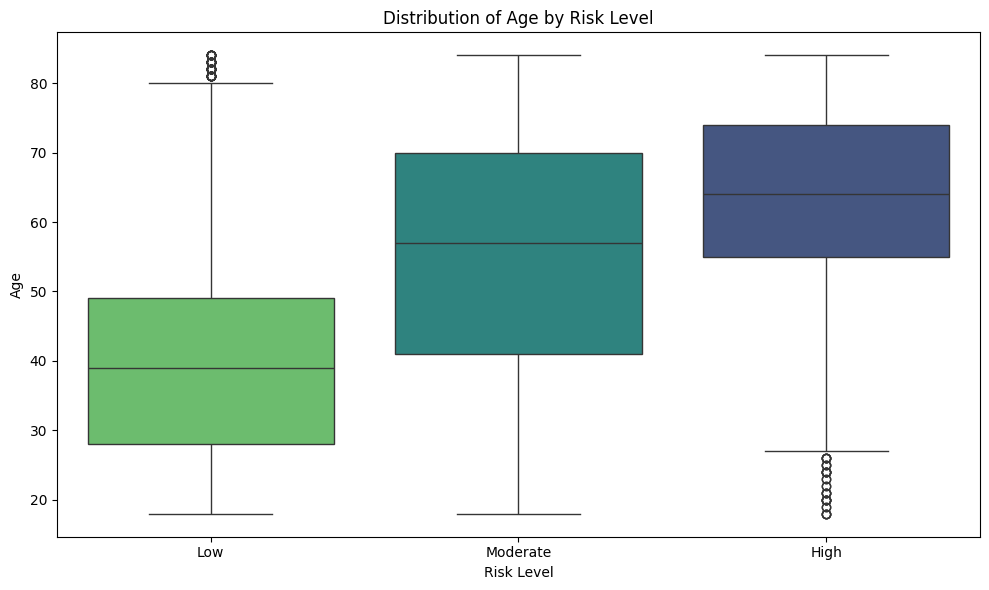

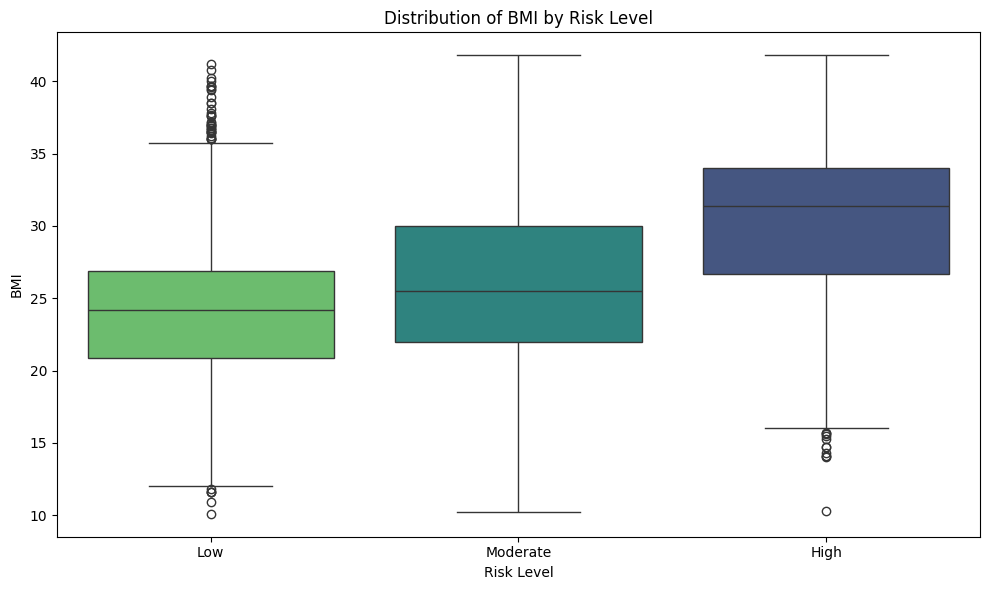

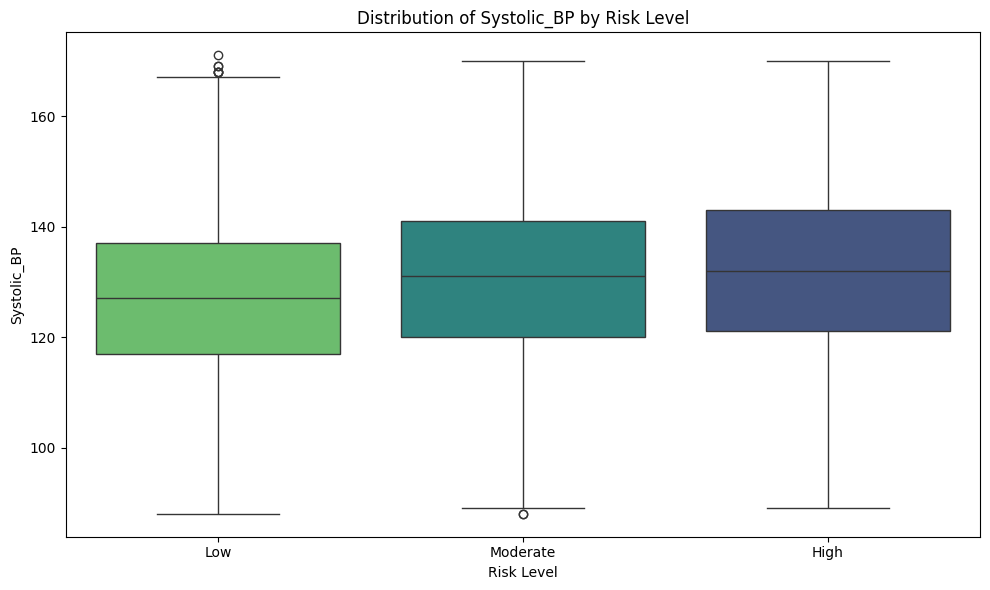

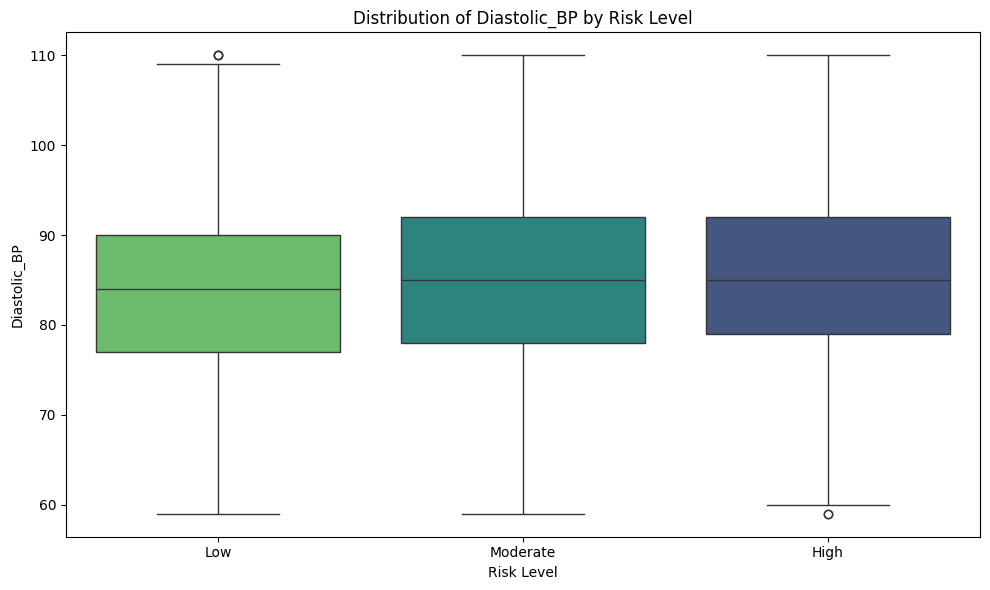

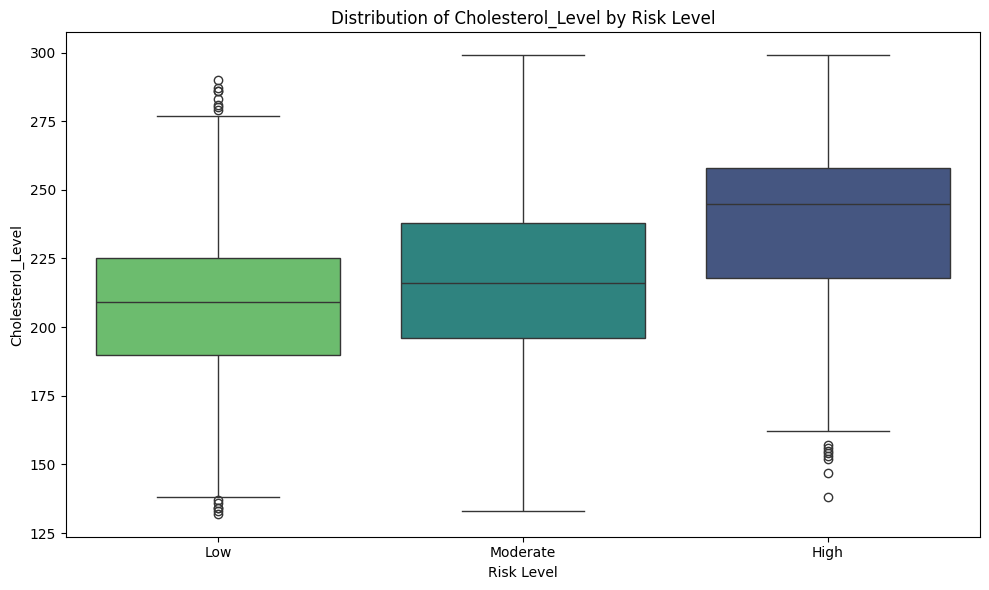

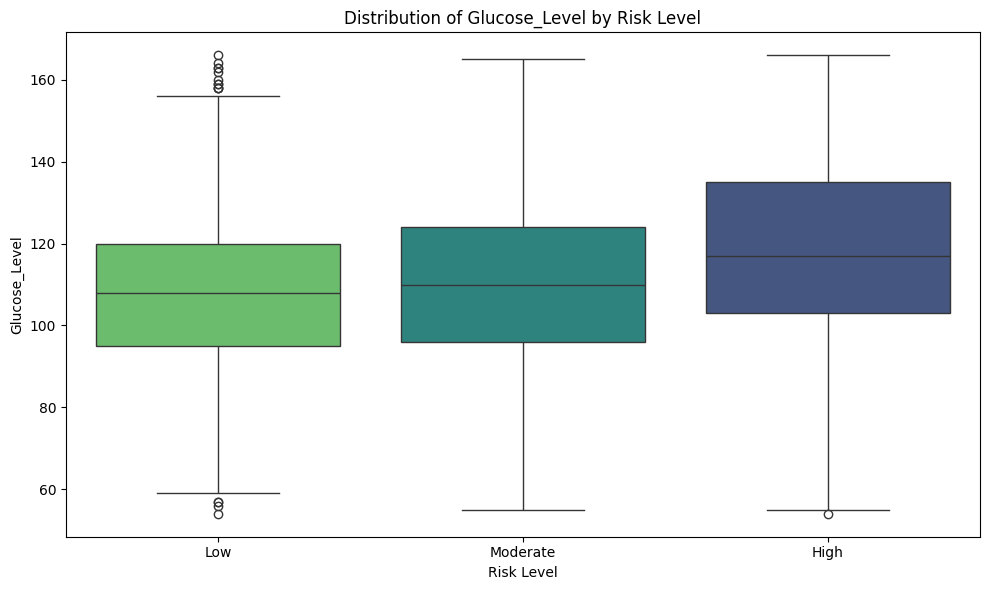

In [17]:
numerical_cols_significant = [
    'Age', 'BMI', 'Systolic_BP', 'Diastolic_BP',
    'Cholesterol_Level', 'Glucose_Level'
]
risk_order = ['Low', 'Moderate', 'High']

for col in numerical_cols_significant:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Risk_Level', y=col, hue='Risk_Level', palette='viridis', order=risk_order, legend=False)
    plt.title(f'Distribution of {col} by Risk Level')
    plt.xlabel('Risk Level')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

**SQL-like Queries** for Patient Grouping and Actionable Insights
We'll use pandas to perform operations similar to SQL queries to group our patient data and extract valuable insights. This will help us understand the characteristics of different patient segments, especially in relation to their Risk_Level and Diagnosed_Condition.

1. Patient Count by Risk Level
First, let's see how many patients fall into each Risk_Level category.


,Risk_Level,Patient_Count
0,High,753
1,Low,2191
2,Moderate,2716


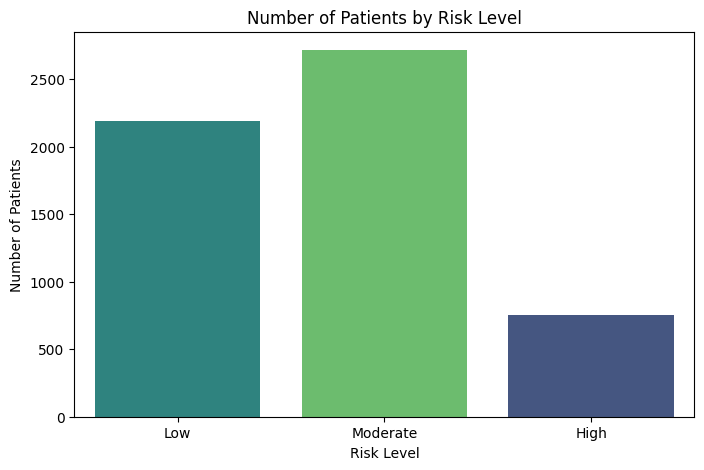

In [18]:
patient_counts_by_risk = df.groupby('Risk_Level').size().reset_index(name='Patient_Count')
display(patient_counts_by_risk)

plt.figure(figsize=(8, 5))
sns.barplot(x='Risk_Level', y='Patient_Count', data=patient_counts_by_risk, order=['Low', 'Moderate', 'High'], palette='viridis', hue='Risk_Level', legend=False)
plt.title('Number of Patients by Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Number of Patients')
plt.show()

2. Average Health Indicators by Risk Level
Next, let's calculate the average of key numerical health indicators for each Risk_Level.

In [19]:
avg_health_by_risk = df.groupby('Risk_Level')[numerical_cols_significant + ['Sleep_Hours', 'Stress_Level']].mean().reset_index()
display(avg_health_by_risk)

,Risk_Level,Age,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Level,Glucose_Level,Sleep_Hours,Stress_Level
0,High,61.782205,30.256972,131.401062,84.922975,237.965471,117.771580,7.000531,5.407703
1,Low,41.453674,23.906481,127.169329,83.734368,207.096303,106.876312,7.014240,5.510726
2,Moderate,55.030191,25.946318,130.377761,85.070692,217.134021,109.910898,6.986377,5.586892


3. Top Diagnosed Conditions within Each Risk Level
Understanding the most common diagnosed conditions within each risk group can provide actionable insights for targeted interventions.

,Risk_Level,Diagnosed_Condition,Count
0,High,Diabetes,160
1,High,Hypertension,153
2,High,Asthma,82
3,High,Heart Disease,80
4,Low,Diabetes,460
5,Low,Hypertension,456
6,Low,Asthma,207
7,Low,Heart Disease,202
8,Moderate,Hypertension,576
9,Moderate,Diabetes,503


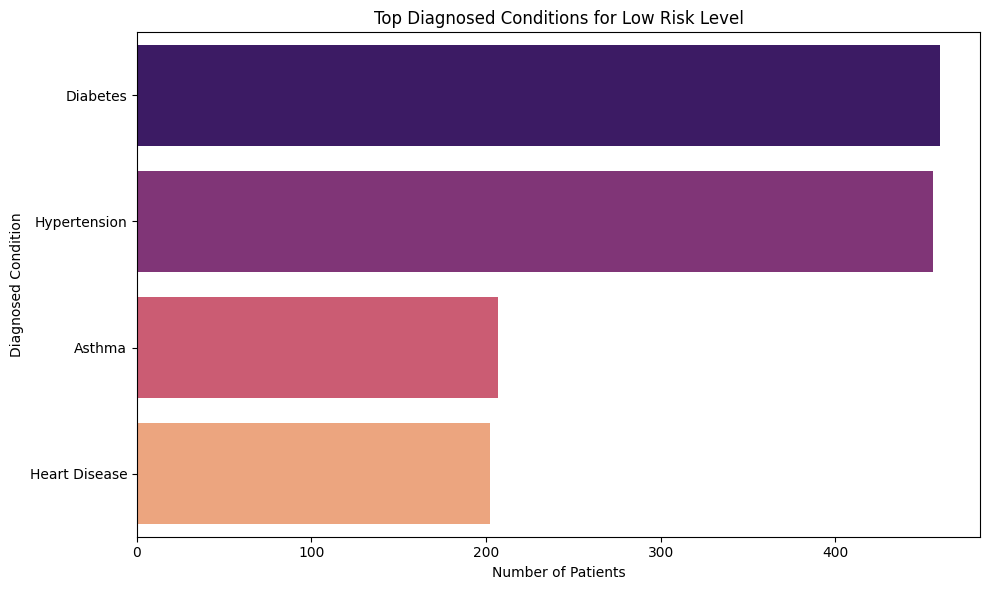

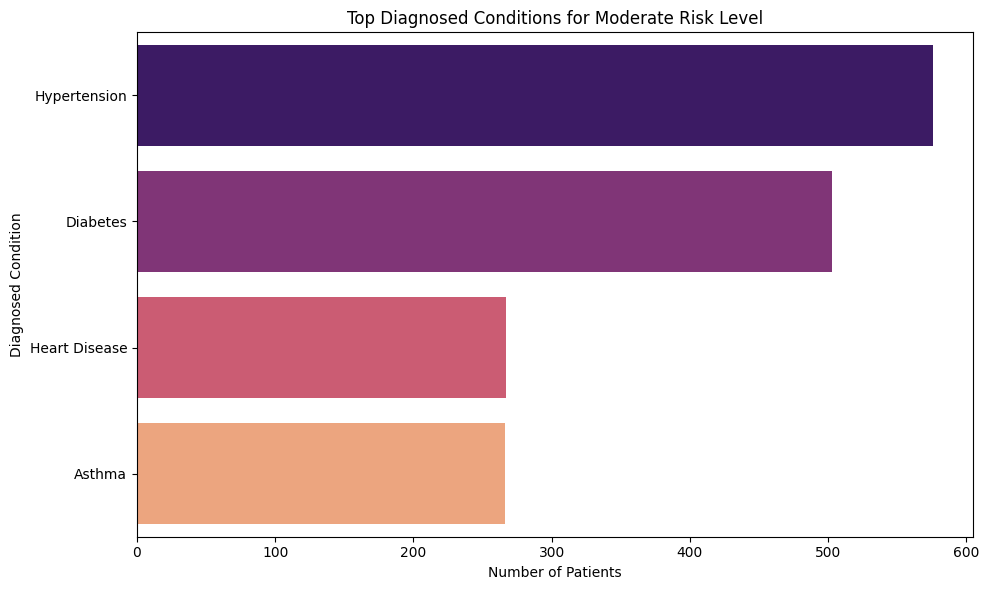

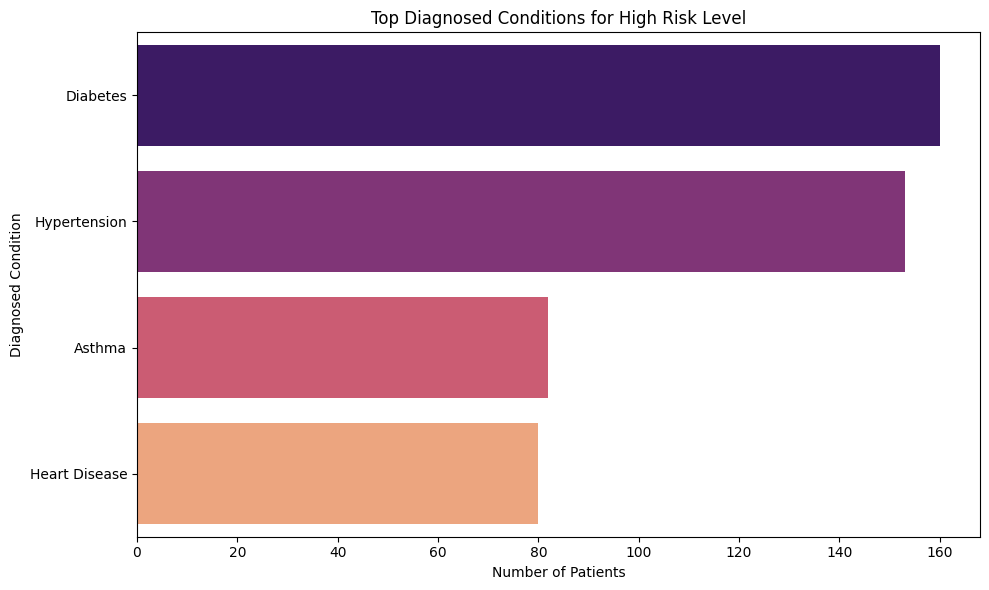

In [20]:
top_conditions_by_risk = df.groupby('Risk_Level')['Diagnosed_Condition'].value_counts().reset_index(name='Count')

# Filter out 'Unknown' condition for better insight into known conditions
top_conditions_by_risk = top_conditions_by_risk[top_conditions_by_risk['Diagnosed_Condition'] != 'Unknown']

# Get top N conditions for each risk level
def get_top_n(group, n=5):
    return group.nlargest(n, 'Count')

top_conditions_by_risk_filtered = top_conditions_by_risk.groupby('Risk_Level').apply(get_top_n, include_groups=False).reset_index()
top_conditions_by_risk_filtered.drop(columns='level_1', inplace=True)

display(top_conditions_by_risk_filtered)

# Visualize top conditions for each risk level
risk_levels_ordered = ['Low', 'Moderate', 'High']
for risk in risk_levels_ordered:
    plt.figure(figsize=(10, 6))
    data_to_plot = top_conditions_by_risk_filtered[top_conditions_by_risk_filtered['Risk_Level'] == risk]
    if not data_to_plot.empty:
        sns.barplot(x='Count', y='Diagnosed_Condition', data=data_to_plot, palette='magma', hue='Diagnosed_Condition', legend=False)
        plt.title(f'Top Diagnosed Conditions for {risk} Risk Level')
        plt.xlabel('Number of Patients')
        plt.ylabel('Diagnosed Condition')
        plt.tight_layout()
        plt.show()
    else:
        print(f"No diagnosed conditions (excluding 'Unknown') for {risk} Risk Level to visualize.")

**Health Reports by Risk Level**

Based on our analysis, here are summary health reports for patients in each risk category, highlighting average health indicators and common diagnosed conditions.



In [21]:
risk_levels_ordered = ['Low', 'Moderate', 'High']

for risk in risk_levels_ordered:
    print(f"## Health Report: {risk} Risk Level\n")

    # Average Health Indicators
    avg_data = avg_health_by_risk[avg_health_by_risk['Risk_Level'] == risk]
    if not avg_data.empty:
        print(f"### Average Health Indicators (for {risk} Risk Patients):\n")
        for col in numerical_cols_significant + ['Sleep_Hours', 'Stress_Level']:
            print(f"- **{col.replace('_', ' ')}:** {avg_data[col].iloc[0]:.2f}")
        print("\n")

    # Top Diagnosed Conditions
    top_conditions = top_conditions_by_risk_filtered[top_conditions_by_risk_filtered['Risk_Level'] == risk]
    if not top_conditions.empty:
        print(f"### Top Diagnosed Conditions (for {risk} Risk Patients):\n")
        for index, row in top_conditions.iterrows():
            print(f"- **{row['Diagnosed_Condition']}:** {row['Count']} patients")
        print("\n")
    else:
        print(f"No specific diagnosed conditions (excluding 'Unknown') found for {risk} Risk Level.\n")

    print("--------------------------------------------------\n")

## Health Report: Low Risk Level

### Average Health Indicators (for Low Risk Patients):

- **Age:** 41.45
- **BMI:** 23.91
- **Systolic BP:** 127.17
- **Diastolic BP:** 83.73
- **Cholesterol Level:** 207.10
- **Glucose Level:** 106.88
- **Sleep Hours:** 7.01
- **Stress Level:** 5.51


### Top Diagnosed Conditions (for Low Risk Patients):

- **Diabetes:** 460 patients
- **Hypertension:** 456 patients
- **Asthma:** 207 patients
- **Heart Disease:** 202 patients


--------------------------------------------------

## Health Report: Moderate Risk Level

### Average Health Indicators (for Moderate Risk Patients):

- **Age:** 55.03
- **BMI:** 25.95
- **Systolic BP:** 130.38
- **Diastolic BP:** 85.07
- **Cholesterol Level:** 217.13
- **Glucose Level:** 109.91
- **Sleep Hours:** 6.99
- **Stress Level:** 5.59


### Top Diagnosed Conditions (for Moderate Risk Patients):

- **Hypertension:** 576 patients
- **Diabetes:** 503 patients
- **Heart Disease:** 267 patients
- **Asthma:** 266 patients



**Predictive Models**
1. This code trains multiple classification models to predict patient risk level.
2. It first cleans and preprocesses the data bt removing unnecceary colums and encoding categorical features.
3. Then it splits the dataset into training and testing sets.
4. Several models are trained and evaluated, and their accuracy scores are compared.
5. Finally, the best-performing model's detailed classification report is displayed.

In [22]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


In [23]:
# ── Copy of cleaned dataframe ──────────────────────────────
work_df = df.copy()

# ── Drop ID/date columns AND leaky columns ──────────────
DROP_COLS = [
    'Patient_ID', 'Patient_Name', 'Last_Visit_Date', 'Visit_Month',
    'Diagnosed_Condition']
work_df = work_df.drop(columns=DROP_COLS, errors='ignore')
work_df = work_df.dropna(subset=['Risk_Level']).copy()


In [24]:
# ── Encode target ───────────────────────────────────────
label_encoder = LabelEncoder()
work_df['Risk_Level_Encoded'] = label_encoder.fit_transform(work_df['Risk_Level'].astype(str))

feature_cols = [c for c in work_df.columns if c not in ['Risk_Level', 'Risk_Level_Encoded']]
X = work_df[feature_cols]
y = work_df['Risk_Level_Encoded']

print("Features used:", feature_cols)
print("Feature count:", len(feature_cols))

Features used: ['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity', 'Diet_Type', 'Family_History', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Level', 'Glucose_Level', 'Sleep_Hours', 'Stress_Level', 'Age_normalized']
Feature count: 17


In [25]:
# ── Column types ────────────────────────────────────────
numeric_cols     = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(exclude=['number']).columns.tolist()

# ── Preprocessing (added StandardScaler for numeric) ────
preprocess = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols)
])

In [26]:
# ── Train-Test Split ─────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Models ───────────────────────────────────────────────
model_dict = {
    'Logistic Regression' : LogisticRegression(max_iter=2000),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=7),
    'SVM'                 : SVC(kernel='rbf'),
}


In [27]:
#5 Fold Cross-Validation + Test Accuracy ──────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_list = []
report_store = {}

for model_name, model_obj in model_dict.items():
    pipe = Pipeline([('preprocess', preprocess), ('model', model_obj)])

    # Cross-val on training data
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')

    # Final fit & test evaluation
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    test_acc = accuracy_score(y_test, preds)

    results_list.append({
        'Model'       : model_name,
        'CV Mean Acc' : round(cv_scores.mean(), 4),
        'CV Std'      : round(cv_scores.std(),  4),
        'Test Acc'    : round(test_acc,          4),
        'Overfit?'    : 'YES' if abs(cv_scores.mean() - test_acc) > 0.03 else 'NO'
    })

    report_store[model_name] = classification_report(
        y_test, preds,
        target_names=label_encoder.classes_,
        output_dict=True
    )
    print(f"  ✔ {model_name} done")


  ✔ Logistic Regression done
  ✔ Decision Tree done
  ✔ Random Forest done
  ✔ Gradient Boosting done
  ✔ KNN done
  ✔ SVM done


In [28]:
# ── Results Table ────────────────────────────────────────
results_df = pd.DataFrame(results_list).sort_values('Test Acc', ascending=False)
print("\n", results_df.to_string(index=False))

# ── Feature Importance Check (leakage detector) ──────────
print("\n--- Top 10 Feature Importances (Gradient Boosting) ---")
gb_pipe = Pipeline([('preprocess', preprocess), ('model', GradientBoostingClassifier(random_state=42))])
gb_pipe.fit(X_train, y_train)

ohe_features = gb_pipe.named_steps['preprocess'] \
                       .named_transformers_['cat'] \
                       .named_steps['onehot'] \
                       .get_feature_names_out(categorical_cols).tolist()
all_features = numeric_cols + ohe_features

feat_imp = pd.Series(
    gb_pipe.named_steps['model'].feature_importances_,
    index=all_features
).sort_values(ascending=False)

print(feat_imp.head(10).round(4))
print("\nIf any single feature > 0.5 importance → data leakage likely!")

# ── Best Model Report ────────────────────────────────────
best_name = results_df.iloc[0]['Model']
print(f"\n=== Best Model: {best_name} ===")
print(pd.DataFrame(report_store[best_name]).T.round(3))


               Model  CV Mean Acc  CV Std  Test Acc Overfit?
  Gradient Boosting       0.9876  0.0024    0.9929       NO
      Decision Tree       0.9863  0.0043    0.9894       NO
      Random Forest       0.9651  0.0061    0.9700       NO
                SVM       0.8474  0.0102    0.8613       NO
Logistic Regression       0.7758  0.0072    0.7853       NO
                KNN       0.7303  0.0135    0.7306       NO

--- Top 10 Feature Importances (Gradient Boosting) ---
Smoking_Status_Current    0.1792
BMI                       0.1743
Cholesterol_Level         0.1561
Age_normalized            0.1484
Physical_Activity_Low     0.1417
Age                       0.0656
Family_History_No         0.0450
Family_History_Yes        0.0440
Glucose_Level             0.0387
Weight_kg                 0.0015
dtype: float64

If any single feature > 0.5 importance → data leakage likely!

=== Best Model: Gradient Boosting ===
              precision  recall  f1-score   support
High              1.000

In [ ]:
# ════════════════════════════════════════════════════════════
# Helper functions for robust user input
# ════════════════════════════════════════════════════════════
def get_numeric(prompt, min_val, max_val):
    while True:
        try:
            value = float(input(f"  {prompt} ({min_val}-{max_val}): "))
            if min_val <= value <= max_val:
                return value
            else:
                print(f"    ❌ Please enter a value between {min_val} and {max_val}.")
        except ValueError:
            print("    ❌ Invalid input. Please enter a number.")

def get_categorical(prompt, choices):
    while True:
        value = input(f"  {prompt} {choices}: ").strip().title()
        if value in choices:
            return value
        else:
            print(f"    ❌ Invalid input. Please choose from {choices}.")

# ════════════════════════════════════════════════════════════
#Collect Patient Input
# ════════════════════════════════════════════════════════════
print("=" * 56)
print("  🏥  HEALTHCARE RISK LEVEL PREDICTOR")
print("=" * 56)
print("  Enter the patient's details below.")
print("  All 16 fields are required.\n")

print("── 📋 PERSONAL DETAILS ──────────────────────────────")
age    = get_numeric("Age (years)",      18,  84)
gender = get_categorical("Gender",       ["Male", "Female", "Other"])

print("\n── 📏 PHYSICAL MEASUREMENTS ─────────────────────────")
height = get_numeric("Height (cm)",      141, 195)
weight = get_numeric("Weight (kg)",      32,  112)
bmi    = get_numeric("BMI",              10,  42)

print("\n── 🚬 LIFESTYLE FACTORS ─────────────────────────────")
smoking  = get_categorical("Smoking Status",      ["Never", "Former", "Current"])
alcohol  = get_categorical("Alcohol Consumption", ["Occasional", "Frequent"])
activity = get_categorical("Physical Activity",   ["High", "Moderate", "Low"])
diet     = get_categorical("Diet Type",           ["Healthy", "Average", "Poor"])
family   = get_categorical("Family History of disease (Yes/No)", ["Yes", "No"])

print("\n── 🩺 CLINICAL MEASUREMENTS ─────────────────────────")
sys_bp  = get_numeric("Systolic Blood Pressure (mmHg)",  88,  171)
dia_bp  = get_numeric("Diastolic Blood Pressure (mmHg)", 59,  110)
chol    = get_numeric("Cholesterol Level (mg/dL)",       132, 299)
glucose = get_numeric("Glucose Level (mg/dL)",           54,  166)

print("\n── 😴 DAILY HABITS ──────────────────────────────────")
sleep  = get_numeric("Sleep Hours per night",  3,  11)
stress = get_numeric("Stress Level (1=Low, 10=High)", 1, 10)

# ════════════════════════════════════════════════════════════
# Build Input DataFrame & Predict
# ════════════════════════════════════════════════════════════
input_data = pd.DataFrame([{
    'Age':                  age,
    'Gender':               gender,
    'Height_cm':            height,
    'Weight_kg':            weight,
    'BMI':                  bmi,
    'Smoking_Status':       smoking,
    'Alcohol_Consumption':  alcohol,
    'Physical_Activity':    activity,
    'Diet_Type':            diet,
    'Family_History':       family,
    'Systolic_BP':          sys_bp,
    'Diastolic_BP':         dia_bp,
    'Cholesterol_Level':    chol,
    'Glucose_Level':        glucose,
    'Sleep_Hours':          sleep,
    'Stress_Level':         stress
}])

# Calculate 'Age_normalized' for the input data
# min_age and max_age are from the original df and available in the kernel state.
input_data['Age_normalized'] = (input_data['Age'] - min_age) / (max_age - min_age)

# Ensure column order matches training
input_data = input_data[feature_cols]

# Assuming best_model and label_encoder are available from previous cells
best_model = Pipeline([('preprocess', preprocess), ('model', model_dict[best_name])])
best_model.fit(X_train, y_train)

prediction_encoded = best_model.predict(input_data)[0]
prediction_label   = label_encoder.inverse_transform([prediction_encoded])[0]
probabilities      = best_model.predict_proba(input_data)[0]
class_labels       = label_encoder.inverse_transform(range(len(probabilities)))

# ════════════════════════════════════════════════════════════
# Display Results
# ════════════════════════════════════════════════════════════
RISK_EMOJI = {"Low": "🟢", "Moderate": "🟡", "High": "🔴"}
RISK_MSG   ={
    "Low":      "Patient shows low risk indicators. Maintain current healthy habits.",
    "Moderate": "Patient has moderate risk. Consider lifestyle improvements and regular check-ups.",
    "High":     "Patient is at HIGH risk. Immediate medical consultation strongly recommended."
}

print("\n" + "=" * 56)
print("  📊  PREDICTION RESULTS")
print("=" * 56)

print(f"\n  Predicted Risk Level:  {RISK_EMOJI[prediction_label]}  {prediction_label.upper()} RISK\n")

print("  Confidence Scores:")
for label, prob in sorted(zip(class_labels, probabilities), key=lambda x: x[1], reverse=True):
    bar = "█" * int(prob * 30)
    print(f"    {label:<10}  {bar:<30}  {prob*100:5.1f}%")

print(f"\n  💬 Advice: {RISK_MSG[prediction_label]}")

print("\n  Input Summary:")
print(f"    Age: {int(age)}  |  Gender: {gender}  |  BMI: {bmi}"
      f"  |  Sys BP: {int(sys_bp)}  |  Stress: {int(stress)}/10")
print(f"    Smoking: {smoking}  |  Activity: {activity}"
      f"  |  Diet: {diet}  |  Family History: {family}")
print("=" * 56)

# ════════════════════════════════════════════════════════════
# Predict Again?
# ════════════════════════════════════════════════════════════
again = input("\n  🔁 Predict for another patient? (yes/no): ").strip().lower()
if again in ["yes", "y"]:
    print("\n  Please re-execute the cell to predict for another patient. 👋\n")
else:
    print("\n  Thank you for using the Healthcare Risk Predictor. 👋\n")

  🏥  HEALTHCARE RISK LEVEL PREDICTOR
  Enter the patient's details below.
  All 16 fields are required.

── 📋 PERSONAL DETAILS ──────────────────────────────
  Age (years) (18-84): 55
  Gender ['Male', 'Female', 'Other']: Female

── 📏 PHYSICAL MEASUREMENTS ─────────────────────────
  Height (cm) (141-195): 177
  Weight (kg) (32-112): 55
  BMI (10-42): 30

── 🚬 LIFESTYLE FACTORS ─────────────────────────────
  Smoking Status ['Never', 'Former', 'Current']: Former
  Alcohol Consumption ['Occasional', 'Frequent']: Frequent
  Physical Activity ['High', 'Moderate', 'Low']: Low
  Diet Type ['Healthy', 'Average', 'Poor']: Healthy
  Family History of disease (Yes/No) ['Yes', 'No']: No.
    ❌ Invalid input. Please choose from ['Yes', 'No'].
  Family History of disease (Yes/No) ['Yes', 'No']: No

── 🩺 CLINICAL MEASUREMENTS ─────────────────────────
  Systolic Blood Pressure (mmHg) (88-171): 88
  Diastolic Blood Pressure (mmHg) (59-110): 59
  Cholesterol Level (mg/dL) (132-299): 132
  Glucose Lev